# I-Python/Jupyter Notebook: Demo for PHY605
### Created by Tzu-Chieh Wei <br> Materials collected and revised from various places: QISKIT Book, Qiskit_algorithm tutorials, etc. 
### Simple VQE illustration

#### Note: we need to import optimizers, such as COBYLA, from qiskit_algorithms.optimizers [need to install: !pip install qiskit_algorithms]; see [the GitHub of qiskit_algorithm](https://github.com/qiskit-community/qiskit-algorithms/tree/main)

In [ ]:
# import packages
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

In [ ]:
# first variational form and Z measurement
def get_var_formZ(params):
    qr = QuantumRegister(1, name="q")
    cr = ClassicalRegister(1, name='c')
    qc = QuantumCircuit(qr, cr)
    qc.u(params[0], params[1], params[2], qr[0])
    qc.measure(qr,cr)
    return qc

In [ ]:
# variational form and X measurement
def get_var_formX(params):
    qr = QuantumRegister(1, name="q")
    cr = ClassicalRegister(1, name='c')
    qc = QuantumCircuit(qr, cr)
    qc.u(params[0], params[1], params[2], qr[0])
    qc.h(qr[0])
    qc.measure(qr,cr)
    return qc

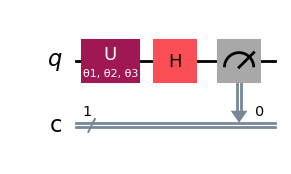

In [ ]:
from qiskit.circuit import Parameter
theta1 = Parameter('θ1')
theta2 = Parameter('θ2')
theta3 = Parameter('θ3')
ex_qc=get_var_formX([theta1,theta2,theta3])
ex_qc.draw('mpl')

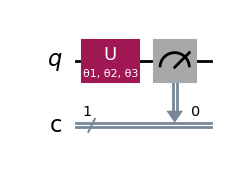

In [ ]:
ex_qc=get_var_formZ([theta1,theta2,theta3])
ex_qc.draw('mpl')

In [ ]:
# proability distribution P(0) and P(1)
def get_probability_distribution(counts):
    mysum=sum([v for  v in counts.values()])
    keys=['0','1']
    output_distr =[]
    for key in keys:
        if key not in counts.keys():
            output_distr.append(0)
        else:
            output_distr.append(counts[key]/mysum)
    return output_distr

In [ ]:
# choose backend to be the simulator
from qiskit_aer import AerSimulator 
backend_sim = AerSimulator()
NUM_SHOTS = 20000

In [ ]:
# define energy for Hamiltonian - B[0] sigma_z - B[1] sigma_x
# B is a list of two objects B=[Bz, Bx]
def energy(output_distrZ,output_distrX,B):
    cost = -B[0]*(output_distrZ[0] -output_distrZ[1])-B[1]* (output_distrX[0] -output_distrX[1])
    return cost

In [ ]:
# the objective function is to evaluate the energy cost by running the quantum circuits
def objective_function(params,B):
    # Obtain quantum circuit instances from the paramters
    qc1 = get_var_formZ(params)
    qc2 = get_var_formX(params)
    # Execute the quantum circuit to obtain the probability distribution associated with the current parameters
    runjob = backend_sim.run([qc1, qc2],shots=NUM_SHOTS)
    results=runjob.result()
    
    # Obtain the counts for each measured state, and convert those counts into a probability vector
    output_distr1 = get_probability_distribution(results.get_counts(qc1))
    output_distr2 = get_probability_distribution(results.get_counts(qc2))
    # Calculate the cost as the distance between the output distribution and the target distribution
    cost = energy(output_distr1,output_distr2,B)
    return cost

In [ ]:
import numpy as np
np.set_printoptions(legacy='1.25')

from qiskit_algorithms.optimizers import COBYLA

nshots=NUM_SHOTS
# Initialize the COBYLA optimizer via Qiskit
optimizer = COBYLA(maxiter=500, disp=True,tol=1e-6)

Bfield =np.random.rand(2)
print('(Bz,Bx)=',Bfield)

# Create the initial parameters (noting that our single qubit variational form has 3 parameters)
params = np.random.rand(3)


def myobject(params):
    fvalue=objective_function(params,Bfield)
    return fvalue

counts = []
values = []
myparams = []
#def store_intermediate_result(eval_count, parameters, mean):  # qiskit_algorithm optimizer does not seem to support callback; only in its VQE
#        #print(eval_count,mean,parameters)
#        counts.append(eval_count)
#        values.append(mean)
#        myparams.append(parameters)

        
        
ret = optimizer.minimize(fun=myobject, x0=params)#, callback=store_intermediate_result) # qiskit_algorithm optimizer does not seem to support callback; only in its VQE

# 
qc1 = get_var_formZ(ret.x)
qc2 = get_var_formX(ret.x)
#from qiskit.visualization import circuit_drawer
#circuit_drawer(qc1)
#circuit_drawer(qc2)  cannot draw using the returned circuit!!
counts1 = backend_sim.run(qc1, shots=nshots).result().get_counts(qc1)
counts2 = backend_sim.run(qc2, shots=nshots).result().get_counts(qc2)
dst1=get_probability_distribution(counts1)
dst2=get_probability_distribution(counts2)


myEnergy=energy(dst1,dst2,Bfield)
exactEnergy=-np.sqrt(Bfield[0]**2+Bfield[1]**2)
print('Num of shots for each circuit=',nshots)
print('Estimated minimum energy=',myEnergy,' vs. exact=',exactEnergy,' error=',myEnergy-exactEnergy)
print("Sigma_z:", dst1)
print("Sigma_x:", dst2)
print("Parameters Found:", ret.x)

(Bz,Bx)= [0.33010973 0.83560583]
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 59   Least value of F = -0.903166554450043
The corresponding X is:
[ 1.13408816 -0.07974696  1.62478611]

Num of shots for each circuit= 20000
Estimated minimum energy= -0.8982138503912896  vs. exact= -0.8984484030145506  error= 0.00023455262326099735
Sigma_z: [0.70975, 0.29025]
Sigma_x: [0.9546, 0.0454]
Parameters Found: [ 1.13408816 -0.07974696  1.62478611]


In [ ]:
print(ret.x)

[ 1.13408816 -0.07974696  1.62478611]


In [ ]:
type(optimizer)

qiskit_algorithms.optimizers.cobyla.COBYLA

In [ ]:
print(ret)

{   'fun': -0.903166554450043,
    'jac': None,
    'nfev': 59,
    'nit': None,
    'njev': None,
    'x': array([ 1.13408816, -0.07974696,  1.62478611])}


In [ ]:
from scipy.optimize import minimize

In [ ]:
Bfield =np.random.rand(2)
print('(Bz,Bx)=',Bfield)
exactEnergy=-np.sqrt(Bfield[0]**2+Bfield[1]**2)
print("Exact energy = {}".format(exactEnergy))
#counts = []
#values = []
#myparams = []
#def store_intermediate_result(parameters):
#        print(parameters)
#        myparams.append(parameters)
counts = []
values = []
myparams = []

def store_intermediateX(x):   # some optimizer in Scipy only store parameters not func values
        #print(eval_count,mean,parameters)
        myparams.append(x)
        counts.append(len(myparams))
    
def callback(intermediate_result):
        #print("   ",intermediate_result)
        #print(intermediate_result['fun'])
        #print(intermediate_result['x'])
        values.append(intermediate_result['fun'])
        myparams.append(intermediate_result['x'])
        counts.append(len(values))

params = np.random.rand(3)     

#Using directly SciPy optimizer
#ret2=minimize(myobject,params,options={ 'disp':True},callback=callback)
ret2=minimize(myobject,params,method='COBYLA',options={'maxiter':500, 'disp':True,'tol':1e-7},callback=store_intermediateX)
#ret2=minimize(myobject,params,method='L-BFGS-B',options={'maxiter':500, 'disp':True,'maxcor': 10, 'ftol': 2.220446049250313e-09, 'gtol': 1e-05, 'eps': 1e-08, 'maxfun': 15000, 'maxiter': 15000, 'iprint': - 1, 'maxls': 20, 'finite_diff_rel_step': None},callback=callback)

(Bz,Bx)= [0.27814778 0.85404866]
Exact energy = -0.8982011517720534
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 52   Least value of F = -0.8959176067427581
The corresponding X is:
[1.11182782 0.03560591 0.3473219 ]



In [ ]:
counts

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31]

In [ ]:
print(ret2)
exactEnergy=-np.sqrt(Bfield[0]**2+Bfield[1]**2)
print('Exact energy= ',exactEnergy)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.8959176067427581
       x: [ 1.112e+00  3.561e-02  3.473e-01]
    nfev: 52
   maxcv: 0.0
Exact energy=  -0.8982011517720534


In [ ]:
params = np.random.rand(3) 
print(params)

counts = []
values = []
myparams = []
#ret2=minimize(myobject,params,method='COBYLA',options={'maxiter':500, 'disp':True,'tol':1e-7},callback=store_intermediateX)
#ret2=minimize(myobject,params,method='L-BFGS-B',options={'maxiter':500, 'disp':True,'maxcor': 10, 'ftol': 1e-08, 'gtol': 1e-06, 'eps': 1e-08, 'maxfun': 15000, 'maxiter': 15000, 'iprint': - 1, 'maxls': 20, 'finite_diff_rel_step': None},callback=callback)
ret2=minimize(myobject,params,method='SLSQP',options={'maxiter':500, 'disp':True,'ftol':1e-7},callback=callback)

[0.57051201 0.42302253 0.6600847 ]
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.36010712150842866
            Iterations: 19
            Function evaluations: 261
            Gradient evaluations: 19


In [ ]:
print(len(counts),len(values))

19 19


In [ ]:
values

[0.010081889979768749,
 0.24388989580474138,
 -0.6907139740535809,
 0.01840108015354977,
 0.19453719174622514,
 -0.08549246710930183,
 0.5443616615100249,
 -0.8208810283685447,
 0.08934254184585318,
 -0.6445037372165079,
 0.31484622395496237,
 0.33322150277859547,
 0.4071161366557009,
 -0.4915035362525017,
 0.6752732427182739,
 0.34656242643668705,
 0.3651342454352083,
 0.35704786322361487,
 0.36206003759307115]

C:\Users\param\AppData\Local\Temp\ipykernel_21044\4163746132.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


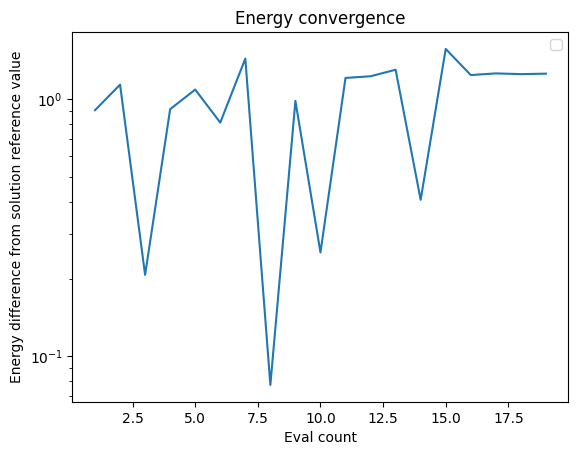

In [ ]:
# It allows to use callback to keep track of convergence
import matplotlib.pyplot as plt 

plt.plot(counts, abs(exactEnergy - values))
plt.xlabel('Eval count')
plt.ylabel('Energy difference from solution reference value')
plt.title('Energy convergence')
plt.yscale('log')
plt.legend(loc='upper right')

In [ ]:
print(ret2)
exactEnergy=-np.sqrt(Bfield[0]**2+Bfield[1]**2)
print(exactEnergy)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.36010712150842866
           x: [-8.440e+03  6.524e+02  1.840e+02]
         nit: 19
         jac: [ 4.650e+05  3.883e+05  6.236e+05]
        nfev: 261
        njev: 19
 multipliers: []
-0.8982011517720534


In [ ]:
ret2=minimize(myobject,params,options={'disp':True},method='BFGS')
#ret2=minimize(myobject,ret2.x,method='BFGS',options={'maxiter':500, 'disp':True,'maxcor': 10, 'ftol': 2.220446049250313e-09, 'gtol': 1e-05, 'eps': 1e-08, 'maxfun': 15000, 'maxiter': 15000, 'iprint': - 1, 'maxls': 20},callback=store_intermediate_result)

         Current function value: -0.660094
         Iterations: 2
         Function evaluations: 84
         Gradient evaluations: 18


c:\Users\param\OneDrive\Desktop\SBU Sem 2\Quantum Programming\Notebooks\.venv\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [ ]:
print(ret2)
exactEnergy=-np.sqrt(Bfield[0]**2+Bfield[1]**2)
print('Exact energy is ',exactEnergy)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -0.6600941628885296
        x: [ 5.705e-01  4.231e-01  6.601e-01]
      nit: 2
      jac: [-8.883e+04  4.394e+04 -1.536e+05]
 hess_inv: [[ 1.471e-01  2.135e-01 -2.990e-01]
            [ 2.135e-01  3.099e-01 -4.340e-01]
            [-2.990e-01 -4.340e-01  6.079e-01]]
     nfev: 84
     njev: 18
Exact energy is  -0.8982011517720534


## Qiskit_algorithms (maintained by the community, not directly by IBM) has built-in packages such as VQE [but as of now, it used version 1 Estimator, need to update to accommodate EstimatorV2]

In [ ]:
from qiskit.quantum_info.operators import Operator, Pauli, SparsePauliOp
#from qiskit.opflow import X, Z, I
from qiskit_algorithms import NumPyEigensolver
#from qiskit.aqua.components.variational_forms import RY, RYRZ, SwapRZ   #deprecated
from qiskit_algorithms import VQE
#from qiskit.circuit.library import TwoLocal  #deprecated
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B, SLSQP, SPSA

In [ ]:
def BzBxH(B):
    return SparsePauliOp(['Z','X'],coeffs=[B[0],B[1]]) #B[0]*Z + B[1]*X 

In [ ]:
H=BzBxH(Bfield)

In [ ]:
def store_intermediate_result(eval_count, parameters, mean, std):
            counts.append(eval_count)
            values.append(mean)
            params.append(parameters)
            deviation.append(std)

In [ ]:
from qiskit.circuit.library import n_local

   ┌──────────┐ ░ ┌──────────┐ ░ ┌──────────┐
q: ┤ Ry(θ[0]) ├─░─┤ Rx(θ[1]) ├─░─┤ Ry(θ[2]) ├
   └──────────┘ ░ └──────────┘ ░ └──────────┘


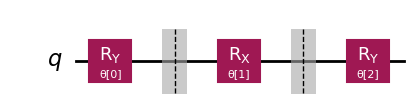

In [ ]:
var_form=n_local(H.num_qubits, "ry", "rx", "linear", reps=1, insert_barriers=True)
print(var_form)
optimizer = COBYLA(maxiter=500, disp=True,tol=1e-6)
counts=[]
values=[]
params=[]
deviation=[]

var_form.draw('mpl')

In [ ]:
from qiskit.primitives import StatevectorEstimator as Estimator
estimator=Estimator()
vqe = VQE(estimator,var_form, optimizer,callback=store_intermediate_result)

In [ ]:
#backend = BasicAer.get_backend('statevector_simulator')
vqe_result = vqe.compute_minimum_eigenvalue(H)
print(vqe_result)

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 77   Least value of F = -0.8982011517720032
The corresponding X is:
[ 4.18367479  3.14159315 -0.84356252]

{   'aux_operators_evaluated': None,
    'cost_function_evals': 77,
    'eigenvalue': -0.8982011517720032,
    'optimal_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000022294D48890>,
    'optimal_parameters': {   ParameterVectorElement(θ[0]): 4.183674788437045,
                              ParameterVectorElement(θ[2]): -0.8435625160602402,
                              ParameterVectorElement(θ[1]): 3.1415931470123084},
    'optimal_point': array([ 4.18367479,  3.14159315, -0.84356252]),
    'optimal_value': -0.8982011517720032,
    'optimizer_evals': None,
    'optimizer_result': <qiskit_algorithms.optimizers.optimizer.OptimizerResult object at 0x00000222970AA350>,
    'optimizer_time': 0.14591383934020996}


In [ ]:
exact_result = NumPyEigensolver().compute_eigenvalues(operator=H)
exact_energy = min(np.real(exact_result.eigenvalues))

In [ ]:
print('VQE result: ',vqe_result.optimal_value,' vs Exact: ',exact_energy)

VQE result:  -0.8982011517720032  vs Exact:  -0.8982011517720535


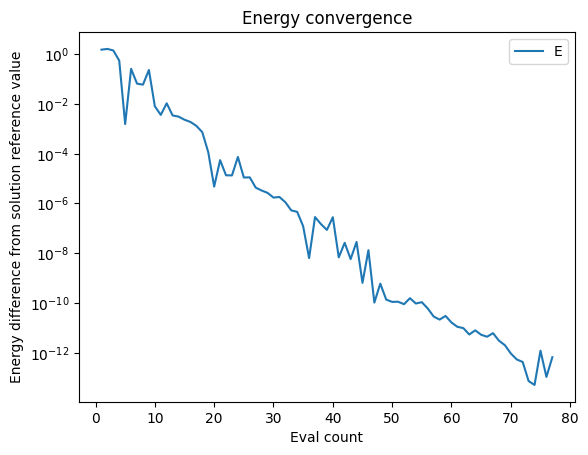

In [ ]:
# It allows to use callback to keep track of convergence
import matplotlib.pyplot as plt 

plt.plot(counts, abs(exact_energy - values))
plt.xlabel('Eval count')
plt.ylabel('Energy difference from solution reference value')
plt.title('Energy convergence')
plt.yscale('log')
plt.legend('E',loc='upper right')

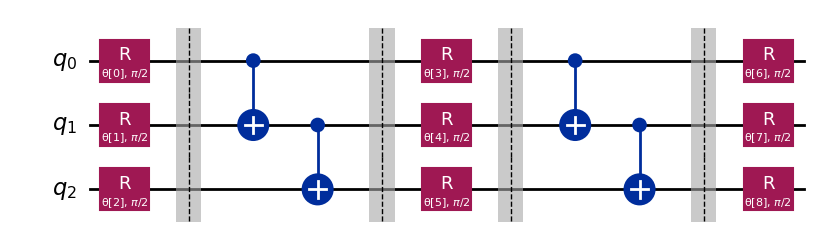

In [ ]:
three = n_local(3, rotation_blocks=['ry'], entanglement_blocks=['cx'], entanglement='linear',reps=2, insert_barriers=True)
three.decompose().draw('mpl')

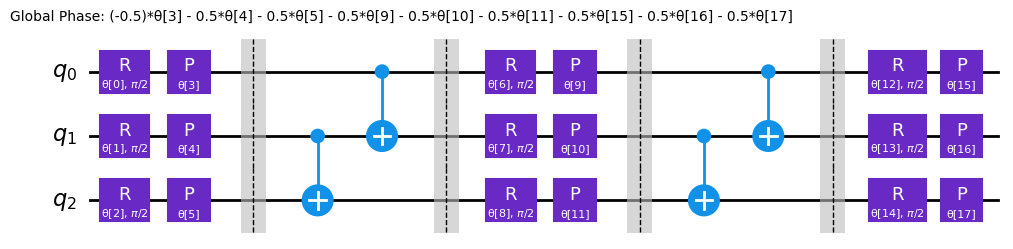

In [ ]:
from qiskit.circuit.library import efficient_su2
ansatz = efficient_su2(3,entanglement='reverse_linear', reps=2,insert_barriers=True)
ansatz.decompose().draw("mpl",style='textbook')

In [ ]:
import qiskit
qiskit.__version__

'2.3.0'